LDA实现完整演示
=== LDA实现演示 ===
数据形状: (300, 2)
类别分布: (array([0, 1, 2]), array([100, 100, 100]))

1. 自定义LDA实现
LDA转换后数据形状: (300, 2)
解释方差比例: [0.82437635 0.17562365]

2. 与sklearn LDA对比
Sklearn解释方差比例: [0.82437635 0.17562365]


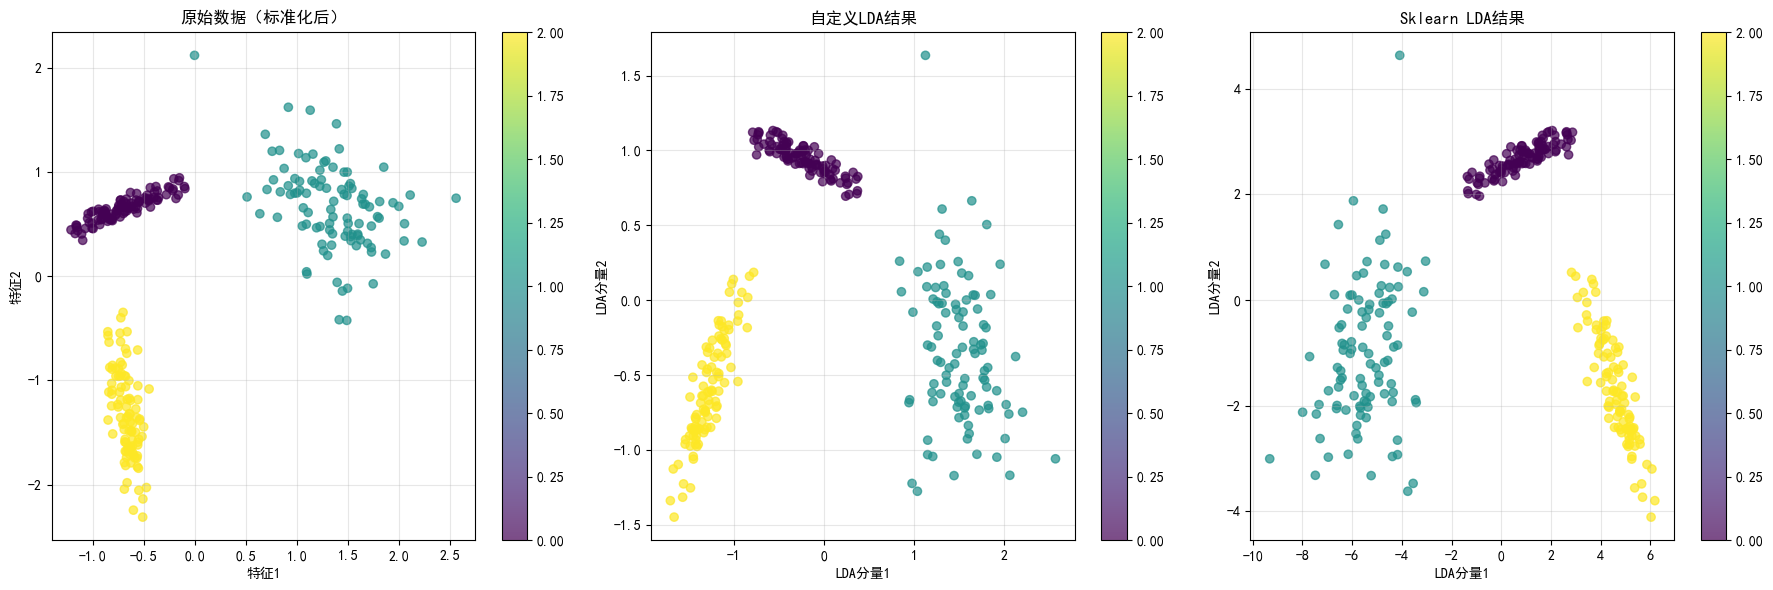


=== 鸢尾花数据集LDA演示 ===
数据形状: (150, 4)
特征名: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
目标类别: ['setosa' 'versicolor' 'virginica']
类别分布: (array([0, 1, 2]), array([50, 50, 50]))
LDA后数据形状: (150, 2)
解释方差比例: [0.9912126 0.0087874]
总解释方差: 1.000


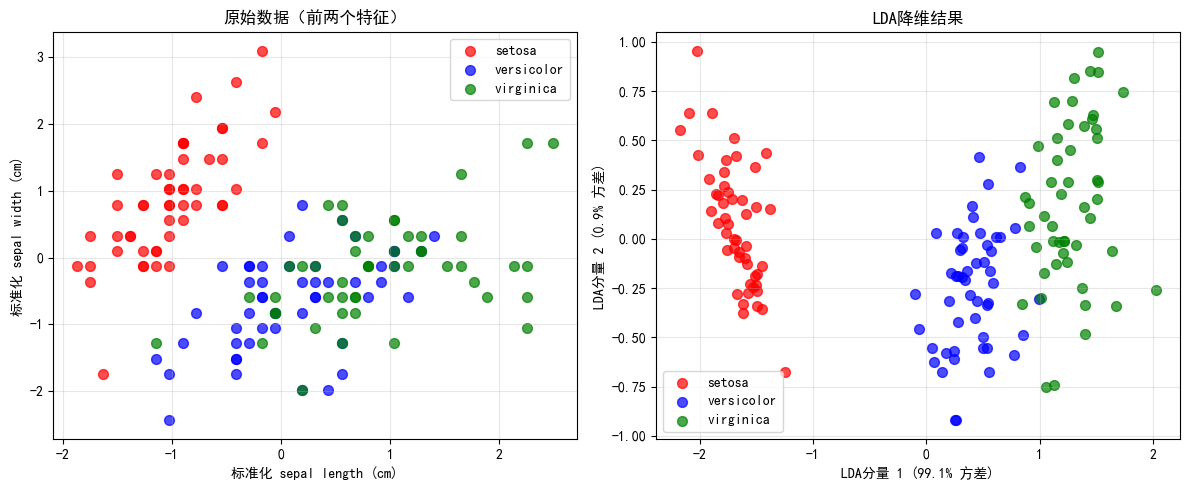


LDA向量组成分析:
LDA分量 1:
  sepal length (cm): -0.151
  sepal width (cm): -0.147
  petal length (cm): 0.856
  petal width (cm): 0.472
LDA分量 2:
  sepal length (cm): 0.007
  sepal width (cm): 0.328
  petal length (cm): -0.572
  petal width (cm): 0.752

=== LDA分类性能评估 ===
训练集形状: (700, 10)
测试集形状: (300, 10)
训练集类别分布: (array([0, 1, 2]), array([234, 232, 234]))

LDA分类准确率: 0.950
Sklearn LDA分类准确率: 0.960


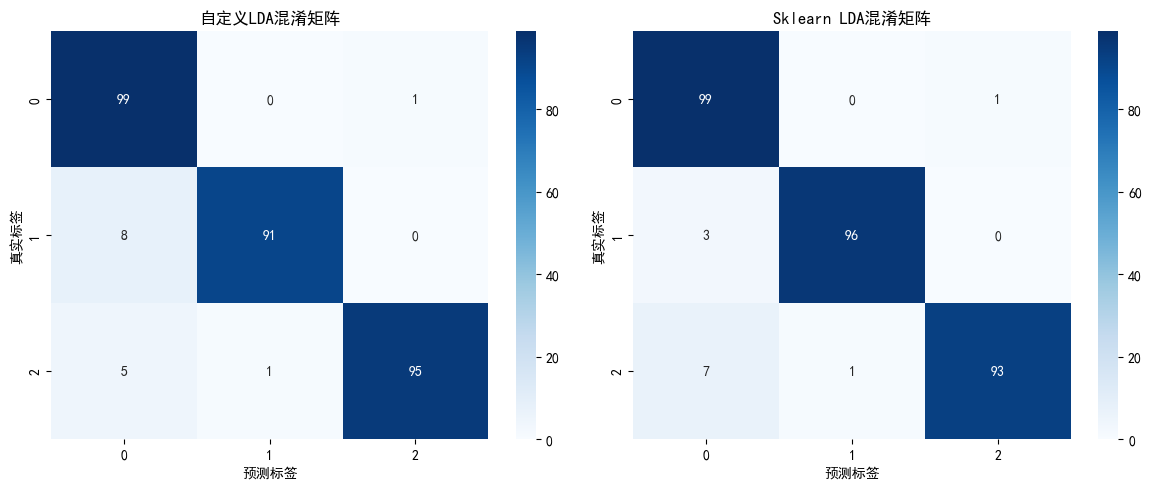

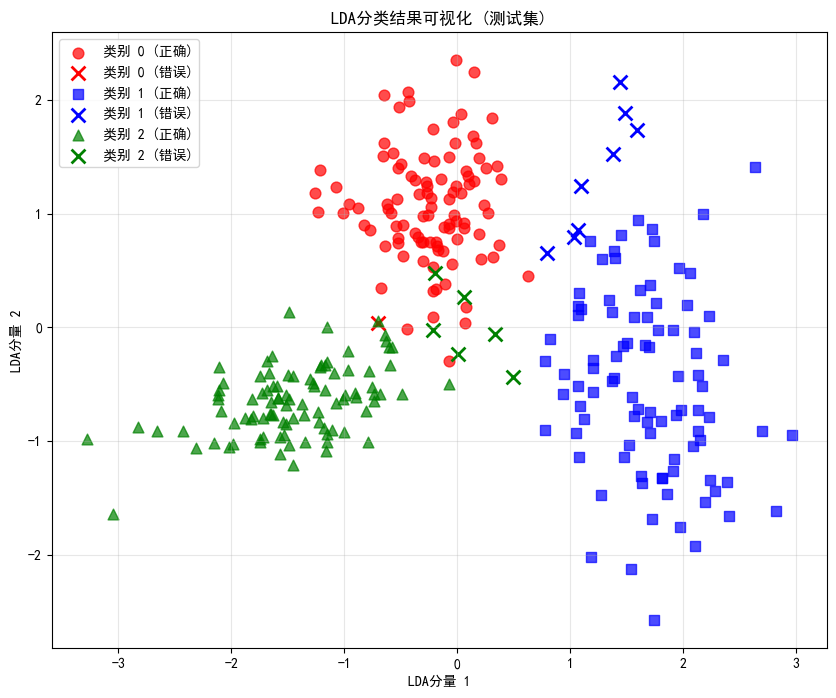


=== LDA与PCA对比 ===
LDA解释方差比例: [0.82437635 0.17562365]
PCA解释方差比例: [0.71350221 0.28649779]


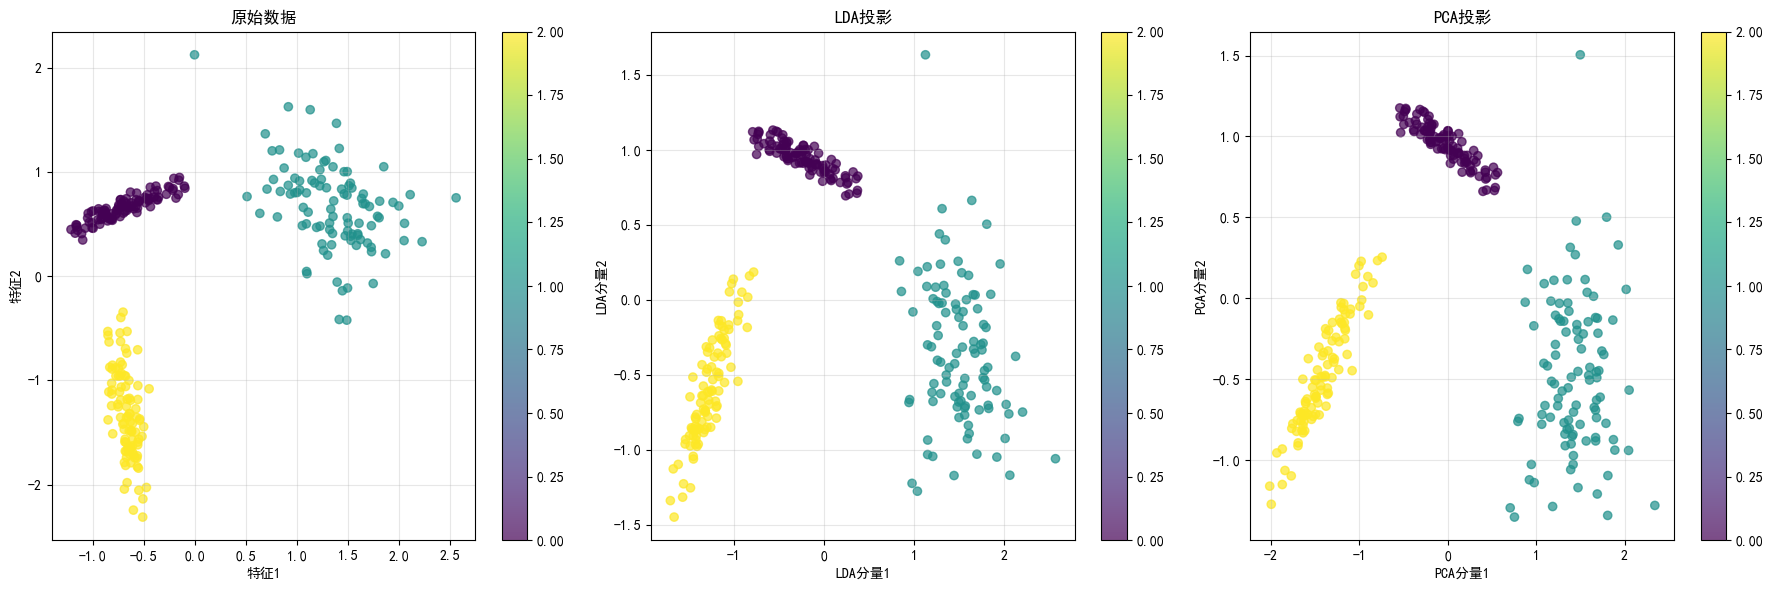

LDA类间可分性: 8.899
PCA类间可分性: 8.899

=== 超简洁LDA使用示例 ===
输入数据形状: (100, 5)
LDA后数据形状: (100, 2)

=== 总结 ===
✓ 实现了完整的LDA算法
✓ 演示了在鸢尾花数据集上的应用
✓ 评估了LDA的分类性能
✓ 对比了LDA与PCA的区别
✓ 提供了超简洁实现版本
✓ 自定义LDA准确率: 0.950, Sklearn LDA准确率: 0.960
✓ LDA类间可分性: 8.899, PCA类间可分性: 8.899


In [1]:
# %load 4-4.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as SklearnLDA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

class SimpleLDA:
    """
    简单LDA实现类
    """
    
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.lda_vectors = None
        self.explained_variance_ratio = None
        self.class_means = None
        self.overall_mean = None
        self.fitted = False
    
    def fit(self, X, y):
        """
        训练LDA模型
        
        参数:
        X: 输入数据，形状为 (n_samples, n_features)
        y: 类别标签，形状为 (n_samples,)
        """
        n_samples, n_features = X.shape
        classes = np.unique(y)
        n_classes = len(classes)
        
        # 确定要保留的组件数
        if self.n_components is None:
            self.n_components = min(n_features, n_classes - 1)
        
        # 计算总体均值
        self.overall_mean = np.mean(X, axis=0)
        
        # 计算类内散度矩阵 (Within-class scatter matrix)
        S_W = np.zeros((n_features, n_features))
        self.class_means = {}
        
        for c in classes:
            X_c = X[y == c]
            self.class_means[c] = np.mean(X_c, axis=0)
            # 类内散度
            S_W += (X_c - self.class_means[c]).T @ (X_c - self.class_means[c])
        
        # 计算类间散度矩阵 (Between-class scatter matrix)
        S_B = np.zeros((n_features, n_features))
        for c in classes:
            n_c = len(X[y == c])
            mean_diff = (self.class_means[c] - self.overall_mean).reshape(-1, 1)
            S_B += n_c * (mean_diff @ mean_diff.T)
        
        # 解决广义特征值问题: S_B * w = lambda * S_W * w
        # 等价于求解: S_W^(-1) * S_B * w = lambda * w
        try:
            # 使用伪逆避免奇异矩阵问题
            eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
        except:
            # 如果伪逆失败，使用SVD
            U, s, Vt = np.linalg.svd(S_W)
            S_W_inv = Vt.T @ np.diag(1/s) @ U.T
            eigenvalues, eigenvectors = np.linalg.eig(S_W_inv @ S_B)
        
        # 按特征值降序排序
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        
        # 选择前n_components个特征向量
        self.lda_vectors = eigenvectors[:, :self.n_components].real
        
        # 计算解释方差比例
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio = eigenvalues[:self.n_components].real / total_variance
        
        self.fitted = True
        return self
    
    def transform(self, X):
        """
        将数据转换到LDA空间
        
        参数:
        X: 输入数据
        
        返回:
        转换后的数据
        """
        if not self.fitted:
            raise ValueError("LDA模型尚未训练，请先调用fit方法")
        
        return X @ self.lda_vectors
    
    def fit_transform(self, X, y):
        """训练并转换数据"""
        return self.fit(X, y).transform(X)
    
    def predict(self, X):
        """
        使用LDA进行分类预测（基于最近类中心）
        """
        if not self.fitted:
            raise ValueError("LDA模型尚未训练")
        
        # 将数据投影到LDA空间
        X_lda = self.transform(X)
        
        # 计算每个类在LDA空间的中心
        class_centers_lda = {}
        for c, mean in self.class_means.items():
            class_centers_lda[c] = mean @ self.lda_vectors
        
        # 预测：选择最近的类中心
        predictions = []
        for sample in X_lda:
            min_dist = float('inf')
            predicted_class = None
            for c, center in class_centers_lda.items():
                dist = np.linalg.norm(sample - center)
                if dist < min_dist:
                    min_dist = dist
                    predicted_class = c
            predictions.append(predicted_class)
        
        return np.array(predictions)
def demo_lda_implementation():
    """
    LDA实现演示
    """
    print("=== LDA实现演示 ===")
    
    # 创建分类数据
    np.random.seed(42)
    X, y = make_classification(
        n_samples=300,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_classes=3,
        n_clusters_per_class=1,
        class_sep=2.0,
        random_state=42
    )
    
    print(f"数据形状: {X.shape}")
    print(f"类别分布: {np.unique(y, return_counts=True)}")
    
    # 标准化数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 1. 使用自定义LDA
    print("\n1. 自定义LDA实现")
    lda = SimpleLDA(n_components=2)
    X_lda = lda.fit_transform(X_scaled, y)
    
    print(f"LDA转换后数据形状: {X_lda.shape}")
    print(f"解释方差比例: {lda.explained_variance_ratio}")
    
    # 2. 与sklearn LDA对比
    print("\n2. 与sklearn LDA对比")
    sklearn_lda = SklearnLDA(n_components=2)
    X_sklearn_lda = sklearn_lda.fit_transform(X_scaled, y)
    
    print(f"Sklearn解释方差比例: {sklearn_lda.explained_variance_ratio_}")
    
    # 可视化比较
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 原始数据
    scatter0 = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[0].set_xlabel('特征1')
    axes[0].set_ylabel('特征2')
    axes[0].set_title('原始数据（标准化后）')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter0, ax=axes[0])
    
    # 自定义LDA结果
    scatter1 = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[1].set_xlabel('LDA分量1')
    axes[1].set_ylabel('LDA分量2')
    axes[1].set_title('自定义LDA结果')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[1])
    
    # Sklearn LDA结果
    scatter2 = axes[2].scatter(X_sklearn_lda[:, 0], X_sklearn_lda[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[2].set_xlabel('LDA分量1')
    axes[2].set_ylabel('LDA分量2')
    axes[2].set_title('Sklearn LDA结果')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    return X_scaled, y, X_lda, X_sklearn_lda

def iris_lda_demo():
    """
    在鸢尾花数据集上演示LDA
    """
    print("\n=== 鸢尾花数据集LDA演示 ===")
    
    # 加载鸢尾花数据集
    iris = load_iris()
    X = iris.data
    y = iris.target
    feature_names = iris.feature_names
    target_names = iris.target_names
    
    print(f"数据形状: {X.shape}")
    print(f"特征名: {feature_names}")
    print(f"目标类别: {target_names}")
    print(f"类别分布: {np.unique(y, return_counts=True)}")
    
    # 标准化数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 应用LDA
    lda = SimpleLDA(n_components=2)
    X_lda = lda.fit_transform(X_scaled, y)
    
    print(f"LDA后数据形状: {X_lda.shape}")
    print(f"解释方差比例: {lda.explained_variance_ratio}")
    print(f"总解释方差: {np.sum(lda.explained_variance_ratio):.3f}")
    
    # 可视化LDA结果
    plt.figure(figsize=(12, 5))
    
    # 原始数据的前两个特征
    plt.subplot(1, 2, 1)
    colors = ['red', 'blue', 'green']
    for i, color in enumerate(colors):
        plt.scatter(X_scaled[y == i, 0], X_scaled[y == i, 1], 
                   color=color, alpha=0.7, label=target_names[i], s=50)
    plt.xlabel('标准化 ' + feature_names[0])
    plt.ylabel('标准化 ' + feature_names[1])
    plt.title('原始数据（前两个特征）')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # LDA结果
    plt.subplot(1, 2, 2)
    for i, color in enumerate(colors):
        plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], 
                   color=color, alpha=0.7, label=target_names[i], s=50)
    plt.xlabel('LDA分量 1 ({:.1f}% 方差)'.format(lda.explained_variance_ratio[0] * 100))
    plt.ylabel('LDA分量 2 ({:.1f}% 方差)'.format(lda.explained_variance_ratio[1] * 100))
    plt.title('LDA降维结果')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 分析LDA向量的组成
    print("\nLDA向量组成分析:")
    for i, vector in enumerate(lda.lda_vectors.T):
        print(f"LDA分量 {i+1}:")
        for j, weight in enumerate(vector):
            print(f"  {feature_names[j]}: {weight:.3f}")
    
    return X_scaled, X_lda, y, feature_names, target_names

def lda_classification_performance():
    """
    LDA分类性能评估
    """
    print("\n=== LDA分类性能评估 ===")
    
    # 创建更复杂的数据
    np.random.seed(42)
    X, y = make_classification(
        n_samples=1000,
        n_features=10,
        n_informative=5,
        n_redundant=2,
        n_classes=3,
        n_clusters_per_class=1,
        class_sep=1.5,
        random_state=42
    )
    
    # 划分训练测试集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"训练集形状: {X_train_scaled.shape}")
    print(f"测试集形状: {X_test_scaled.shape}")
    print(f"训练集类别分布: {np.unique(y_train, return_counts=True)}")
    
    # 使用LDA进行分类
    lda = SimpleLDA(n_components=2)
    X_train_lda = lda.fit_transform(X_train_scaled, y_train)
    
    # 预测
    y_pred = lda.predict(X_test_scaled)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nLDA分类准确率: {accuracy:.3f}")
    
    # 与sklearn LDA对比
    sklearn_lda = SklearnLDA()
    sklearn_lda.fit(X_train_scaled, y_train)
    y_pred_sklearn = sklearn_lda.predict(X_test_scaled)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    print(f"Sklearn LDA分类准确率: {sklearn_accuracy:.3f}")
    
    # 可视化混淆矩阵
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 自定义LDA混淆矩阵
    cm_custom = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('自定义LDA混淆矩阵')
    axes[0].set_xlabel('预测标签')
    axes[0].set_ylabel('真实标签')
    
    # Sklearn LDA混淆矩阵
    cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
    sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Sklearn LDA混淆矩阵')
    axes[1].set_xlabel('预测标签')
    axes[1].set_ylabel('真实标签')
    
    plt.tight_layout()
    plt.show()
    
    # 可视化LDA投影
    X_test_lda = lda.transform(X_test_scaled)
    
    plt.figure(figsize=(10, 8))
    colors = ['red', 'blue', 'green']
    markers = ['o', 's', '^']
    
    for i, color in enumerate(colors):
        # 正确分类的点
        correct_mask = (y_test == i) & (y_pred == i)
        plt.scatter(X_test_lda[correct_mask, 0], X_test_lda[correct_mask, 1], 
                   color=color, marker=markers[i], s=60, alpha=0.7, 
                   label=f'类别 {i} (正确)')
        
        # 错误分类的点
        wrong_mask = (y_test == i) & (y_pred != i)
        plt.scatter(X_test_lda[wrong_mask, 0], X_test_lda[wrong_mask, 1], 
                   color=color, marker='x', s=100, linewidth=2,
                   label=f'类别 {i} (错误)')
    
    plt.xlabel('LDA分量 1')
    plt.ylabel('LDA分量 2')
    plt.title('LDA分类结果可视化 (测试集)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return X_train_scaled, X_test_scaled, y_train, y_test, accuracy, sklearn_accuracy

def lda_vs_pca_comparison():
    """
    LDA与PCA对比
    """
    print("\n=== LDA与PCA对比 ===")
    
    # 创建有明显类别结构的数据
    np.random.seed(42)
    X, y = make_classification(
        n_samples=300,
        n_features=2,
        n_informative=2,
        n_redundant=0,
        n_classes=3,
        n_clusters_per_class=1,
        class_sep=2.0,
        random_state=42
    )
    
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 应用LDA
    lda = SimpleLDA(n_components=2)
    X_lda = lda.fit_transform(X_scaled, y)
    
    # 应用PCA
    pca = SimplePCA(n_components=2)  # 使用之前实现的PCA
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"LDA解释方差比例: {lda.explained_variance_ratio}")
    print(f"PCA解释方差比例: {pca.explained_variance_ratio_}")
    
    # 可视化对比
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 原始数据
    scatter0 = axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[0].set_xlabel('特征1')
    axes[0].set_ylabel('特征2')
    axes[0].set_title('原始数据')
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter0, ax=axes[0])
    
    # LDA结果
    scatter1 = axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[1].set_xlabel('LDA分量1')
    axes[1].set_ylabel('LDA分量2')
    axes[1].set_title('LDA投影')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[1])
    
    # PCA结果
    scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
    axes[2].set_xlabel('PCA分量1')
    axes[2].set_ylabel('PCA分量2')
    axes[2].set_title('PCA投影')
    axes[2].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # 计算类间可分性度量
    def calculate_separability(X_proj, y):
        """计算投影后数据的类间可分性"""
        classes = np.unique(y)
        overall_mean = np.mean(X_proj, axis=0)
        
        # 类间方差
        between_var = 0
        for c in classes:
            X_c = X_proj[y == c]
            n_c = len(X_c)
            mean_c = np.mean(X_c, axis=0)
            between_var += n_c * np.sum((mean_c - overall_mean) ** 2)
        
        # 类内方差
        within_var = 0
        for c in classes:
            X_c = X_proj[y == c]
            mean_c = np.mean(X_c, axis=0)
            within_var += np.sum((X_c - mean_c) ** 2)
        
        return between_var / within_var if within_var > 0 else 0
    
    lda_separability = calculate_separability(X_lda, y)
    pca_separability = calculate_separability(X_pca, y)
    
    print(f"LDA类间可分性: {lda_separability:.3f}")
    print(f"PCA类间可分性: {pca_separability:.3f}")
    
    return X_scaled, y, X_lda, X_pca, lda_separability, pca_separability

# 之前实现的PCA类（为了完整性）
class SimplePCA:
    """简单的PCA实现"""
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
    
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        self.components_ = eigenvectors[:, sorted_idx[:self.n_components]].T
        self.explained_variance_ratio_ = eigenvalues[sorted_idx[:self.n_components]] / np.sum(eigenvalues)
        return self
    
    def transform(self, X):
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_.T)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

# 超简洁版本
def quick_lda(X, y, n_components=2):
    """
    超简洁的LDA实现
    
    参数:
    X: 输入数据 (n_samples, n_features)
    y: 类别标签 (n_samples,)
    n_components: LDA分量数量
    
    返回:
    转换后的数据
    """
    n_features = X.shape[1]
    classes = np.unique(y)
    
    # 总体均值
    overall_mean = np.mean(X, axis=0)
    
    # 类内散度矩阵
    S_W = np.zeros((n_features, n_features))
    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        S_W += (X_c - mean_c).T @ (X_c - mean_c)
    
    # 类间散度矩阵
    S_B = np.zeros((n_features, n_features))
    for c in classes:
        n_c = len(X[y == c])
        mean_diff = (np.mean(X[y == c], axis=0) - overall_mean).reshape(-1, 1)
        S_B += n_c * (mean_diff @ mean_diff.T)
    
    # 求解广义特征值问题
    eigenvalues, eigenvectors = np.linalg.eig(np.linalg.pinv(S_W) @ S_B)
    
    # 选择前n_components个特征向量
    sorted_idx = np.argsort(eigenvalues)[::-1]
    lda_vectors = eigenvectors[:, sorted_idx[:n_components]].real
    
    return X @ lda_vectors

if __name__ == "__main__":
    print("LDA实现完整演示")
    print("=" * 60)
    
    # 运行所有演示
    X_orig, y_orig, X_custom_lda, X_sklearn_lda = demo_lda_implementation()
    
    X_iris, X_iris_lda, y_iris, feature_names, target_names = iris_lda_demo()
    
    X_train, X_test, y_train, y_test, acc_custom, acc_sklearn = lda_classification_performance()
    
    X_comp, y_comp, X_lda_comp, X_pca_comp, lda_sep, pca_sep = lda_vs_pca_comparison()
    
    # 超简洁版本使用示例
    print("\n=== 超简洁LDA使用示例 ===")
    np.random.seed(42)
    test_data = np.random.randn(100, 5)
    test_labels = np.random.choice([0, 1, 2], 100)
    test_lda = quick_lda(test_data, test_labels, n_components=2)
    print(f"输入数据形状: {test_data.shape}")
    print(f"LDA后数据形状: {test_lda.shape}")
    
    print("\n=== 总结 ===")
    print("✓ 实现了完整的LDA算法")
    print("✓ 演示了在鸢尾花数据集上的应用")
    print("✓ 评估了LDA的分类性能")
    print("✓ 对比了LDA与PCA的区别")
    print("✓ 提供了超简洁实现版本")
    print(f"✓ 自定义LDA准确率: {acc_custom:.3f}, Sklearn LDA准确率: {acc_sklearn:.3f}")
    print(f"✓ LDA类间可分性: {lda_sep:.3f}, PCA类间可分性: {pca_sep:.3f}")